# Προβολή Συντεταγμένων Κέντρων Κλινικής Δοκιμής για Χαρτογράφηση με τη PROC GPROJECT


## Περίληψη

Μια ομάδα κλινικών λειτουργιών χρειάζεται να απεικονίσει το γεωγραφικό αποτύπωμα μιας πολυκεντρικής δοκιμής Φάσης III σε έναν επίπεδο χάρτη. Αυτό το notebook δημιουργεί συνθετικές συντεταγμένες γεωγραφικού πλάτους/μήκους για κέντρα δοκιμής συγκεντρωμένα γύρω από πέντε περιφερειακούς κόμβους των ΗΠΑ, και στη συνέχεια χρησιμοποιεί την **PROC GPROJECT** για να μετατρέψει τις σφαιρικές συντεταγμένες σε τιμές Καρτεσιανού X/Y χρησιμοποιώντας τρεις μεθόδους προβολής (Albers ίσου εμβαδού, Lambert ισογώνια με προσαρμοσμένους τυπικούς παράλληλους και περιφερειακή περικοπή, και Γνωμονική με κέντρο τις ηπειρωτικές ΗΠΑ), απεικονίζοντας πώς η επιλογή προβολής και η περικοπή επηρεάζουν έναν χάρτη κέντρων.


## Πηγές Δεδομένων

| Σύνολο δεδομένων | Γραμμές | Βασικές μεταβλητές | Περιγραφή |
|---------|------|---------------|-------------|
| `trial_sites` | 60 (5 κόμβοι x 12 κέντρα) | `site_id` (αναγνωριστικό $8), `region` (περιοχή, $9), `x` (γεωγραφικό μήκος, μοίρες, ανατολικό-θετικό), `y` (γεωγραφικό πλάτος, μοίρες), `enroll` (εγγεγραμμένοι συμμετέχοντες), `segment` (αναγνωριστικό τμήματος χάρτη) | Συνθετικές τοποθεσίες κέντρων κλινικής δοκιμής Φάσης III διάσπαρτες γύρω από πέντε περιφερειακούς κόμβους των ΗΠΑ (Δύση, Μέση Δύση, Βορειοανατολικά, Νότος, Νοτιοανατολικά) χρησιμοποιώντας τυχαία μετατόπιση `rand('normal')` και αριθμούς εγγραφής `rand('poisson')` |


# Προβολή Συντεταγμένων Κέντρων Κλινικής Δοκιμής με τη PROC GPROJECT

Όταν ένας χορηγός εκτελεί μια γεωγραφικά διάσπαρτη δοκιμή Φάσης III, η ομάδα κλινικών λειτουργιών συχνά θέλει έναν ενιαίο χάρτη που να δείχνει κάθε ερευνητικό κέντρο, με μέγεθος ή χρώμα ανάλογα με την εγγραφή. Οι τοποθεσίες κέντρων φτάνουν ως **ζεύγη γεωγραφικού μήκους/πλάτους**, αλλά ένας επίπεδος χάρτης χρειάζεται **επίπεδες συντεταγμένες X/Y**. Η `PROC GPROJECT` εκτελεί αυτή τη μετατροπή από σφαιρικό σε Καρτεσιανό, εφαρμόζοντας μια χαρτογραφική προβολή ώστε οι αποστάσεις και οι περιοχές να αποδίδονται λογικά.

Σε αυτό το notebook:

1. Δημιουργούμε συνθετικές συντεταγμένες κέντρων συγκεντρωμένες γύρω από πέντε περιφερειακούς κόμβους των ΗΠΑ.
2. Εφαρμόζουμε την προεπιλεγμένη προβολή ίσου εμβαδού **Albers**.
3. Εφαρμόζουμε μια ισογώνια προβολή **Lambert** με προσαρμοσμένους τυπικούς παράλληλους και περικοπή στις συνεχόμενες ΗΠΑ.
4. Εφαρμόζουμε μια **Γνωμονική** προβολή με κέντρο το γεωγραφικό μέσο της χώρας, διατηρώντας τις αρχικές συντεταγμένες με το `ASIS`.

Όλα είναι αυτοτελή: χωρίς εξωτερικά αρχεία, χωρίς δίκτυο.


## Βήμα 1 — Δημιουργία συνθετικών συντεταγμένων κέντρων δοκιμής

Δίνουμε seed στη γεννήτρια τυχαίων αριθμών με `call streaminit` για αναπαραγωγιμότητα, και στη συνέχεια τοποθετούμε 12 κέντρα γύρω από καθέναν από πέντε πόλεις-κόμβους περιφέρειας. Τα γεωγραφικά μήκη αποθηκεύονται ως ανατολικά-θετικά σε μοίρες (αρνητικά για το Δυτικό Ημισφαίριο) και τα γεωγραφικά πλάτη σε μοίρες. Κάθε γραμμή φέρει επίσης έναν αριθμό εγγραφής και μια μεταβλητή `segment` (η GPROJECT διατηρεί τις μη-συντεταγμένες στήλες κατά την προβολή).


In [1]:
ΔΕΔΟΜΕΝΑ trial_sites;
    CALL streaminit(20260531);
    LENGTH site_id $8 region $32;
    /* Five U.S. regional hub centers: longitude (east+), latitude */
    ARRAY clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    ARRAY clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);

    ΕΠΑΝΑΛΗΨΗ hub = 1 ΕΩΣ 5;
        ΕΑΝ hub = 1 ΤΟΤΕ region = 'Δύση';
        ΑΛΛΙΩΣ ΕΑΝ hub = 2 ΤΟΤΕ region = 'Μέση Δύση';
        ΑΛΛΙΩΣ ΕΑΝ hub = 3 ΤΟΤΕ region = 'Βορειοανατολικά';
        ΑΛΛΙΩΣ ΕΑΝ hub = 4 ΤΟΤΕ region = 'Νότος';
        ΑΛΛΙΩΣ region = 'Νοτιοανατολικά';
        ΕΠΑΝΑΛΗΨΗ s = 1 ΕΩΣ 12;
            site_id = cats('S', PUT(hub, z1.), PUT(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* γεωγραφικό μήκος, μοίρες */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* γεωγραφικό πλάτος, μοίρες */
            enroll  = round(rand('poisson', 60));           /* εγγεγραμμένοι συμμετέχοντες */
            segment = 1;
            ΕΞΟΔΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ hub s;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=trial_sites(obs=10) ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ site_id="Αναγνωριστικό Κέντρου" region="Περιοχή"
          x="Γεωγραφικό Μήκος (x)" y="Γεωγραφικό Πλάτος (y)"
          enroll="Εγγεγραμμένοι" segment="Τμήμα Χάρτη";
    TITLE "Δείγμα Συνθετικών Κέντρων Κλινικής Δοκιμής (Μη προβεβλημένα lon/lat)";
ΕΚΤΕΛΕΣΗ;

                          Δείγμα Συνθετικών Κέντρων Κλινικής Δοκιμής (Μη προβεβλημένα lon/lat)                          

  Obs                      Αναγνωριστικό Κέντρου         Περιοχή                 Γεωγραφικό Μήκος (x)                  Γεωγραφικό Πλάτος (y)               Εγγεγραμμένοι            Τμήμα Χάρτη
    1  S101                                       Δύση                                -121.6437232216                          37.7677668495                          65                      1
    2  S102                                       Δύση                                -120.7384024716                          37.5083287903                          61                      1
    3  S103                                       Δύση                                -121.5133780284                          37.8633933883                          72                      1
    4  S104                                       Δύση                                -121.2086817368         


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Βήμα 2 — Προεπιλεγμένη προβολή ίσου εμβαδού Albers

Η κωνική προβολή ίσου εμβαδού **Albers** είναι η προεπιλογή της GPROJECT και μια λογική επιλογή για έναν χάρτη σε κλίμακα χώρας όπου η διατήρηση της *σχετικής περιοχής* έχει σημασία (π.χ., σύγκριση του μεγέθους περιφερειακών λεκανών κάλυψης).

Επειδή οι συντεταγμένες μας αποθηκεύονται σε **μοίρες** με **ανατολικό-θετικό γεωγραφικό μήκος**, καθορίζουμε τις επιλογές `DEGREE` και `EASTLONG`. Η δήλωση `ID` ονομάζει τη μεταβλητή που προσδιορίζει μοναδικά κάθε μονάδα· οι προβεβλημένες επίπεδες συντεταγμένες γράφονται πίσω στα `x` και `y` στο σύνολο δεδομένων `OUT=`.


In [2]:
ΔΙΑΔΙΚΑΣΙΑ GPROJECT ΔΕΔΟΜΕΝΑ=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=sites_albers(obs=10) ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ site_id="Αναγνωριστικό Κέντρου" region="Περιοχή"
          x="Προβεβλημένο X (Albers)" y="Προβεβλημένο Y (Albers)"
          enroll="Εγγεγραμμένοι" segment="Τμήμα Χάρτη";
    TITLE "Κέντρα Δοκιμής Μετά την Προβολή Ίσου Εμβαδού Albers (επίπεδο X/Y)";
ΕΚΤΕΛΕΣΗ;

                          Δείγμα Συνθετικών Κέντρων Κλινικής Δοκιμής (Μη προβεβλημένα lon/lat)                          

                           Κέντρα Δοκιμής Μετά την Προβολή Ίσου Εμβαδού Albers (επίπεδο X/Y)                            

  Obs                      Αναγνωριστικό Κέντρου         Περιοχή              Προβεβλημένο X (Albers)              Προβεβλημένο Y (Albers)               Εγγεγραμμένοι            Τμήμα Χάρτη
    1  S101                                       Δύση                                   -0.346124731                         0.0516986079                          65                      1
    2  S102                                       Δύση                                  -0.3353644139                         0.0440400181                          61                      1
    3  S103                                       Δύση                                  -0.3439609675                         0.0528501365                          72                    


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Βήμα 3 — Ισογώνια προβολή Lambert με προσαρμοσμένους παράλληλους και περικοπή

Η ισογώνια κωνική προβολή **Lambert** διατηρεί το *σχήμα και τις τοπικές γωνίες*, κάτι προτιμότερο όταν ο χάρτης χρησιμοποιείται για πλοήγηση ή για επικάλυψη κατευθυντικών χαρακτηριστικών. Για τις συνεχόμενες ΗΠΑ, οι τυπικοί παράλληλοι κοντά στις 33 μοίρες Β και 45 μοίρες Β είναι συμβατικοί, οπότε τους ορίζουμε ρητά με τα `PARALLEL1=` και `PARALLEL2=`.

Περιορίζουμε επίσης τον χάρτη στο παράθυρο των συνεχόμενων ΗΠΑ χρησιμοποιώντας τις επιλογές περικοπής `LATMIN=`, `LATMAX=`, `LONGMIN=`, και `LONGMAX=`. Κάθε κέντρο που πέφτει έξω από αυτό το πλαίσιο γεωγραφικού πλάτους/μήκους αποβάλλεται πριν από την προβολή, οπότε ο αριθμός παρατηρήσεων εξόδου μπορεί να είναι χαμηλότερος από τον αριθμό εισόδου.


In [3]:
ΔΙΑΔΙΚΑΣΙΑ GPROJECT ΔΕΔΟΜΕΝΑ=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=sites_lambert(obs=10) ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ site_id="Αναγνωριστικό Κέντρου" region="Περιοχή"
          x="Προβεβλημένο X (Lambert)" y="Προβεβλημένο Y (Lambert)"
          enroll="Εγγεγραμμένοι" segment="Τμήμα Χάρτη";
    TITLE "Κέντρα Δοκιμής Μετά την Ισογώνια Προβολή Lambert (περικομμένα στις συνεχόμενες ΗΠΑ)";
ΕΚΤΕΛΕΣΗ;

                           Κέντρα Δοκιμής Μετά την Προβολή Ίσου Εμβαδού Albers (επίπεδο X/Y)                            

                  Κέντρα Δοκιμής Μετά την Ισογώνια Προβολή Lambert (περικομμένα στις συνεχόμενες ΗΠΑ)                   

  Obs                      Αναγνωριστικό Κέντρου         Περιοχή              Προβεβλημένο X (Lambert)              Προβεβλημένο Y (Lambert)               Εγγεγραμμένοι            Τμήμα Χάρτη
    1  S101                                       Δύση                                   -0.3473024124                          0.0279382533                          65                      1
    2  S102                                       Δύση                                   -0.3365626234                          0.0201991247                          61                      1
    3  S103                                       Δύση                                   -0.3451238364                          0.0290365995                          72            


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Βήμα 4 — Γνωμονική προβολή με κέντρο τη χώρα, διατηρώντας τα αρχικά

Η αζιμουθιακή προβολή **Γνωμονική** αποδίδει κάθε μέγιστο κύκλο ως ευθεία γραμμή, κάτι χρήσιμο όταν θέλετε να συλλογιστείτε τη συντομότερη διαδρομή μεταξύ κέντρων (για παράδειγμα, τον σχεδιασμό ενός ταξιδιού επίσκεψης παρακολουθητή κέντρου). Η παραμόρφωση αυξάνεται με την απόσταση από τον πόλο προβολής, οπότε κεντράρουμε τον πόλο στο γεωγραφικό μέσο των ηπειρωτικών ΗΠΑ με `POLELAT=39` και `POLELONG=-98`.

Η επιλογή `ASIS` λέει στη GPROJECT να διατηρήσει τις αρχικές μη προβεβλημένες συντεταγμένες μαζί με τις προβεβλημένες τιμές, ώστε το σύνολο δεδομένων εξόδου να φέρει και τα επίπεδα `X`/`Y` και τα αρχικά `LONG`/`LAT` — χρήσιμο για τη σύνδεση μετρικών εγγραφής πίσω σε οποιοδήποτε από τα δύο συστήματα συντεταγμένων.

Η δήλωση `PARMENTRY` παρουσιάζεται ως εναλλακτικός τρόπος παροχής παραμέτρων προβολής ως υπερισχύσεις κλειδί=τιμή.


In [4]:
ΔΙΑΔΙΚΑΣΙΑ GPROJECT ΔΕΔΟΜΕΝΑ=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=sites_gnomon(obs=10) ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ site_id="Αναγνωριστικό Κέντρου" region="Περιοχή"
          x="Προβεβλημένο X (Gnomonic)" y="Προβεβλημένο Y (Gnomonic)"
          long="Γεωγραφικό Μήκος (αρχικό)" lat="Γεωγραφικό Πλάτος (αρχικό)"
          enroll="Εγγεγραμμένοι" segment="Τμήμα Χάρτη";
    TITLE "Κέντρα Δοκιμής Μετά την Γνωμονική Προβολή (το ASIS διατηρεί τα αρχικά LONG/LAT)";
ΕΚΤΕΛΕΣΗ;

                  Κέντρα Δοκιμής Μετά την Ισογώνια Προβολή Lambert (περικομμένα στις συνεχόμενες ΗΠΑ)                   

                    Κέντρα Δοκιμής Μετά την Γνωμονική Προβολή (το ASIS διατηρεί τα αρχικά LONG/LAT)                     

  Obs                      Αναγνωριστικό Κέντρου         Περιοχή              Προβεβλημένο X (Gnomonic)              Προβεβλημένο Y (Gnomonic)               Εγγεγραμμένοι            Τμήμα Χάρτη                       Γεωγραφικό Μήκος (αρχικό)                        Γεωγραφικό Πλάτος (αρχικό)
    1  S101                                       Δύση                                    -0.3343477981                           0.0213614461                          65                      1                                 -121.6437232216                                     37.7677668495
    2  S102                                       Δύση                                    -0.3221611694                           0.0134152735                          61  


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Βήμα 5 — Απόδοση του χάρτη προβεβλημένων κέντρων

Το νόημα της προβολής είναι να σχεδιάσουμε τον χάρτη. Τροφοδοτούμε το σύνολο δεδομένων `OUT=` του Albers απευθείας στην **PROC SGPLOT**, σχεδιάζοντας τα επίπεδα `X`/`Y` και χρωματίζοντας κάθε δείκτη ανά `region`. Επειδή η προβολή διατήρησε τη σχετική γεωγραφία, οι πέντε συστάδες κόμβων προσγειώνονται στις αναμενόμενες γωνίες του γραφήματος — Δύση στα αριστερά, Βορειοανατολικά επάνω δεξιά, Νότος και Νοτιοανατολικά κατά μήκος της βάσης — δίνοντας στις κλινικές λειτουργίες το πιστό ως προς την περιοχή αποτύπωμα που περιγράφηκε στην περίληψη.


                    Κέντρα Δοκιμής Μετά την Γνωμονική Προβολή (το ASIS διατηρεί τα αρχικά LONG/LAT)                     




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


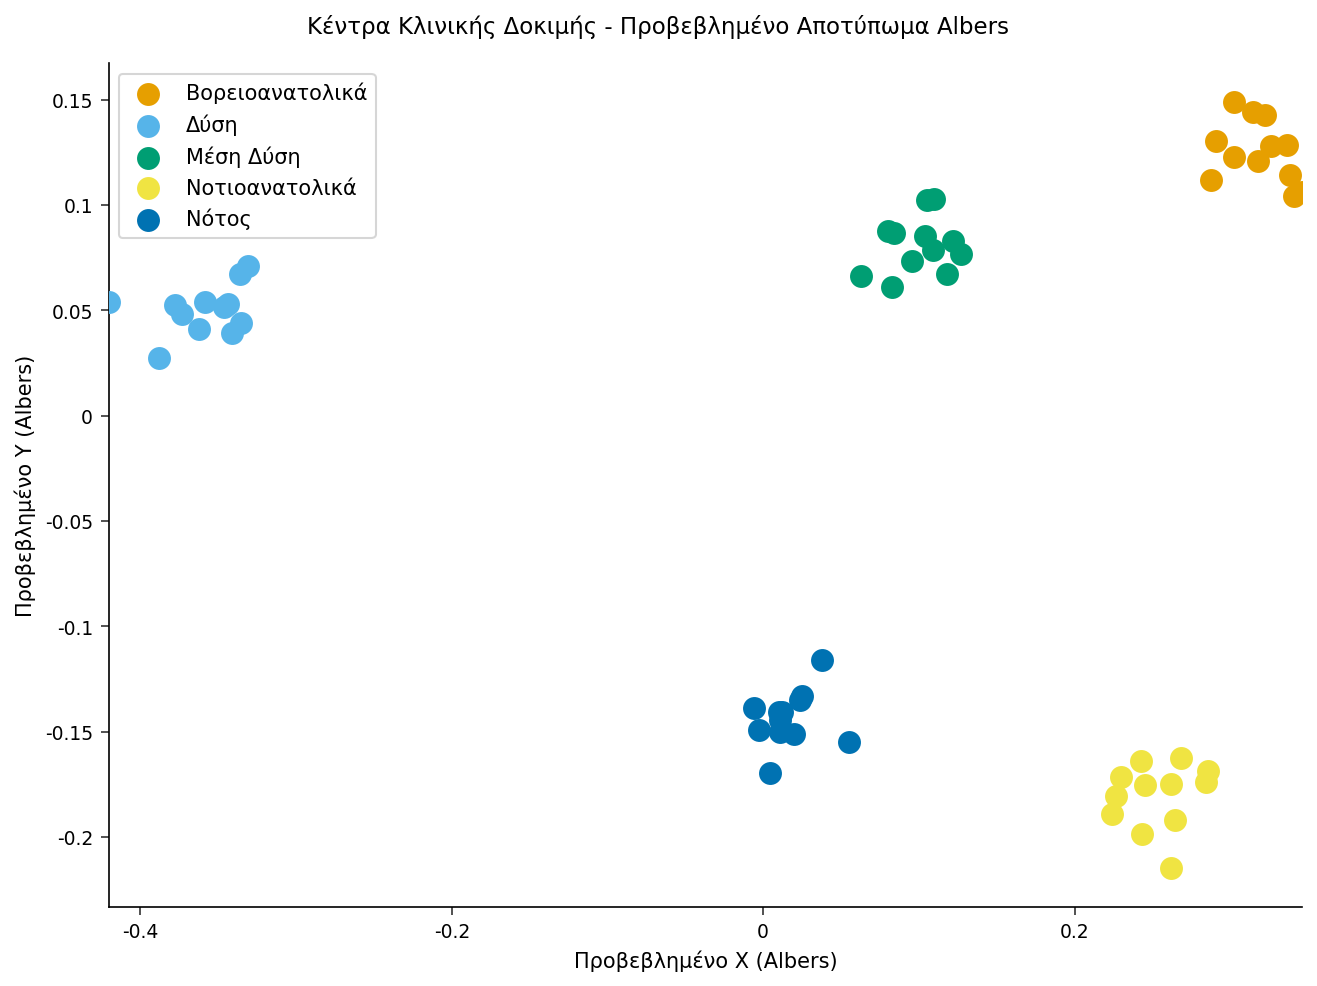

In [5]:
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=sites_albers;
    SCATTER x=x y=y / GROUP=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS ΕΤΙΚΕΤΑ='Προβεβλημένο X (Albers)';
    YAXIS ΕΤΙΚΕΤΑ='Προβεβλημένο Y (Albers)';
    TITLE 'Κέντρα Κλινικής Δοκιμής - Προβεβλημένο Αποτύπωμα Albers';
ΕΚΤΕΛΕΣΗ;

## Ερμηνεία των αποτελεσμάτων

- Η **Albers (Βήμα 2)** μετέτρεψε όλα τα 60 κέντρα σε επίπεδες συντεταγμένες διατηρώντας τη σχετική περιοχή — οι συστάδες Δύση, Μέση Δύση, Βορειοανατολικά, Νότος, και Νοτιοανατολικά διατηρούν το αναλογικό χωρικό τους αποτύπωμα, που είναι η σωστή βάση για έναν πιστό ως προς την περιοχή θερμικό χάρτη εγγραφής.
- Η **Lambert με περικοπή (Βήμα 3)** διατήρησε το τοπικό σχήμα και, εφαρμόζοντας το παράθυρο `LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX`, απέβαλε τα συνθετικά κέντρα που ήταν διάσπαρτα έξω από τις συνεχόμενες ΗΠΑ — εδώ ο αριθμός έπεσε από 60 σε 58, οπότε οι δύο εκτός-πλέγματος συντεταγμένες που διαφορετικά θα τέντωναν τον χάρτη αφαιρέθηκαν πριν από την προβολή.
- Η **Γνωμονική με `ASIS` (Βήμα 4)** κεντράρισε την προβολή στο εσωτερικό της χώρας και, χάρη στο `ASIS`, παρήγαγε ένα σύνολο δεδομένων που φέρει τόσο τα προβεβλημένα `X`/`Y` όσο και τα αρχικά `LONG`/`LAT`. Οι μέγιστοι κύκλοι εμφανίζονται ως ευθείες γραμμές, οπότε οι ευθείες αποστάσεις σε αυτόν τον χάρτη προσεγγίζουν τις πραγματικές συντομότερες διαδρομές μεταξύ κέντρων.
- Το **αποδοσμένο αποτύπωμα (Βήμα 5)** επιβεβαιώνει ότι η προβολή λειτούργησε: η απεικόνιση των `X`/`Y` του Albers ανά περιοχή τοποθετεί τις πέντε συστάδες κόμβων στις αναμενόμενες γωνίες του επιπέδου, τον πιστό ως προς την περιοχή χάρτη κέντρων που υποσχέθηκε η περίληψη.

**Συμπέρασμα για τις κλινικές λειτουργίες:** η προβολή δεν είναι διακοσμητική. Επιλέξτε **Albers** για πιστότητα περιοχής στην πυκνότητα εγγραφής, **Lambert** για επικαλύψεις πιστές ως προς το σχήμα με περιφερειακή περικοπή, και **Γνωμονική** όταν η απόσταση ταξιδιού μεταξύ κέντρων καθοδηγεί την ανάλυση. Όπως δείχνει το Βήμα 5, το προβεβλημένο σύνολο δεδομένων `OUT=` περνάει απευθείας στην PROC SGPLOT (ή PROC GMAP) για να αποδώσει τον τελικό χάρτη κέντρων.
